In [69]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np

CARGAMOS LIBRERÍAS Y DATOS

In [70]:
from google.colab import drive
drive.mount('/mnt/drive')

Drive already mounted at /mnt/drive; to attempt to forcibly remount, call drive.mount("/mnt/drive", force_remount=True).


In [71]:
os.getcwd()
os.chdir('/mnt/drive/MyDrive/ciencia_de_datos')
os.listdir()

['netflix_data.csv',
 'democracy_data.csv',
 'democracy_data.gsheet',
 'output_file.csv',
 'regicor.csv',
 'customers_1.csv',
 'introduc_ciencia_de_datos',
 'billboard.csv',
 'datos_crudos.csv',
 'Salud_Mental_20260412.csv',
 'datos_crudos_tarea.csv',
 'Chicago_wards.csv',
 'licenses.csv',
 'xeek_train_subset.csv',
 'reviews.csv',
 'Transporte_Aéreo_–_Tráfico_por_Equipo_(Colombia)_20260518.csv']

In [72]:
df = pd.read_csv('Transporte_Aéreo_–_Tráfico_por_Equipo_(Colombia)_20260518.csv')

In [73]:
df #revisamos el dataframe

,Año,Mes,Sigla Empresa,Nombre,Origen,Nombre Origen,Ciudad Origen,Departamento Origen,Pais Origen,Continente Origen,...,Tipo Vuelo,Tráfico,Número de Vuelos,Horas Bloque,Sillas Ofrecidas,Pasajeros A Bordo,Pasajeros Tránsito,Carga Ofrecida (Kg.),Carga + Correo A Bordo (Kg.),Carga Tránsito (Kg.)
0,"2,020",1,0EC,SAE,7IY,HATO SAN JOSE,LA PRIMAVERA,VICHADA,COLOMBIA,SURAMÉRICA,...,T,N,1,2.25,0,5,0,0,0,0
1,"2,020",1,0EC,SAE,7KA,SAN CAMILO,CUMARIBO,VICHADA,COLOMBIA,SURAMÉRICA,...,T,N,1,1.58,0,2,0,0,18,0
2,"2,020",1,0EC,SAE,9DI,SAN FELIPE,SAN FELIPE,GUAINÍA,COLOMBIA,SURAMÉRICA,...,T,N,1,1.08,0,3,0,0,9,0
3,"2,020",1,0EC,SAE,9DI,SAN FELIPE,SAN FELIPE,GUAINÍA,COLOMBIA,SURAMÉRICA,...,T,N,3,3.24,0,6,0,0,36,0
4,"2,020",1,0EC,SAE,A13,MIRITI PARANA,MIRITÍ - PARANÁ,AMAZONAS,COLOMBIA,SURAMÉRICA,...,T,N,1,1.08,0,1,0,0,9,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199788,"2,025",12,WFL,WORLD2FLY,CTG,CARTAGENA - RAFAEL NUÑEZ,CARTAGENA DE INDIAS,BOLÍVAR,COLOMBIA,SURAMÉRICA,...,C,I,5,54.91,"1,425","1,302",0,"224,180",0,0
199789,"2,025",12,WFL,WORLD2FLY,MAD,BARAJAS,MADRID,ESPAÑA,ESPAÑA,EUROPA,...,C,I,1,11.55,388,129,0,"44,836",0,0
199790,"2,025",12,WFL,WORLD2FLY,MAD,BARAJAS,MADRID,ESPAÑA,ESPAÑA,EUROPA,...,R,I,10,105.27,"4,320","4,209",0,"425,000","11,030",0
199791,"2,025",12,WFL,WORLD2FLY,MAD,BARAJAS,MADRID,ESPAÑA,ESPAÑA,EUROPA,...,C,I,5,52.44,"1,425","1,372",0,"224,180",0,0


#INSPECCIÓN INICIAL

In [74]:
df.info() #revisamos el dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 199793 entries, 0 to 199792
Data columns (total 27 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   Año                           199793 non-null  object
 1   Mes                           199793 non-null  int64 
 2   Sigla Empresa                 199793 non-null  object
 3   Nombre                        199793 non-null  object
 4   Origen                        199793 non-null  object
 5   Nombre Origen                 199793 non-null  object
 6   Ciudad Origen                 199793 non-null  object
 7   Departamento Origen           184019 non-null  object
 8   Pais Origen                   199793 non-null  object
 9   Continente Origen             199793 non-null  object
 10  Destino                       199793 non-null  object
 11  Nombre Destino                199793 non-null  object
 12  Ciudad Destino                199793 non-null  object
 13 

In [75]:
#analizamos el dataset, los nulos, las columnas numericas y los tipos.
print(df.shape)
print('*'*40)
print(df.isnull().sum())
print('*'*40)
print(df.describe())
print('*'*40)
print(df.dtypes)

(199793, 27)
****************************************
Año                                 0
Mes                                 0
Sigla Empresa                       0
Nombre                              0
Origen                              0
Nombre Origen                       0
Ciudad Origen                       0
Departamento Origen             15774
Pais Origen                         0
Continente Origen                   0
Destino                             0
Nombre Destino                      0
Ciudad Destino                      0
Departamento Destino            14473
Pais Destino                        0
Continente Destino                  0
Tipo de Equipo                      0
Tipo Vuelo                          0
Tráfico                             0
Número de Vuelos                    0
Horas Bloque                        0
Sillas Ofrecidas                    0
Pasajeros A Bordo                  20
Pasajeros Tránsito                  0
Carga Ofrecida (Kg.)              

Tenemos 4 columnas con valores faltantes, según el tamaño del dataset, sin valores faltantes pequeños, estamos hablando que el departamento origen que es la columna con la mayor cantidad de valores faltantes tiene 15774, mientras que el dataset tiene 199793 filas... Es decir, menos del 10% del dataset... Aquí podriamos revisar la columna y entender un poco el comportamiento, tambien podriamos decidir hacer un drop.na sobre esa columna, total mantendríamos mas del 90% del dataset intacto para pruebas.

In [76]:
print(df['Departamento Origen'].describe()) #Revisamos la categoría
print('*'*70)
print(df['Departamento Origen'].unique()) #Revisamos los departamentos de salida de los vuelos

count           184019
unique              86
top       BOGOTÁ, D.C.
freq             32598
Name: Departamento Origen, dtype: object
**********************************************************************
['VICHADA' 'GUAINÍA' 'AMAZONAS' 'CAQUETÁ' 'META' 'ANTIOQUIA' 'VAUPÉS'
 'CÓRDOBA' 'HUILA' 'CASANARE' 'GUAVIARE' 'ARAUCA' 'CESAR' 'SANTANDER'
 'NORTE DE SANTANDER' 'CHILE' 'BOGOTÁ, D.C.' 'ESTADOS UNIDOS' 'BOYACÁ'
 'PANAMÁ' 'CUNDINAMARCA' 'PUTUMAYO' 'ATLÁNTICO' 'BOLÍVAR' 'MAGDALENA'
 'TOLIMA' 'ARCHIPIÉLAGO DE SAN ANDRÉS, PROVIDENCIA Y SANTA CATALINA'
 'MÉXICO' 'ANTILLAS HOLANDESAS' 'VALLE' 'SUCRE' 'CHOCÓ' 'LA GUAJIRA'
 'PERÚ' 'RISARALDA' 'COSTA RICA' 'NARIÑO' 'CAUCA' 'CALDAS' 'QUINDÍO'
 'ECUADOR' 'CANADÁ' 'ESPAÑA' 'FRANCIA' 'TRINIDAD Y TOBAGO' 'PUERTO RICO'
 'ARGENTINA' 'PARAGUAY' 'BRASIL' 'GUATEMALA' 'CUBA' 'INGLATERRA' 'BOLIVIA'
 'ALEMANIA' 'URUGUAY' 'REPUBLICA DOMINICANA' 'EL SALVADOR' 'VENEZUELA'
 'HOLANDA' 'JAMAICA' 'HAITÍ' 'HONDURAS' 'ISLA DOMINICA' 'BÉLGICA'
 'BARBADOS' 'ITALIA' 'N

In [77]:
#Para la estadística descriptiva usamos directamente describe, solo tenemos 2 variables numéricas
df.describe()

,Mes,Número de Vuelos
count,199793.000000,199793.000000
mean,6.623575,13.740326
std,3.502094,35.392005
min,1.000000,1.000000
25%,3.000000,1.000000
50%,7.000000,3.000000
75%,10.000000,13.000000
max,12.000000,885.000000


#Distribuciones univariadas

0          1
1          1
2          1
3          1
4          1
          ..
199788    12
199789    12
199790    12
199791    12
199792    12
Name: Mes, Length: 199793, dtype: int64


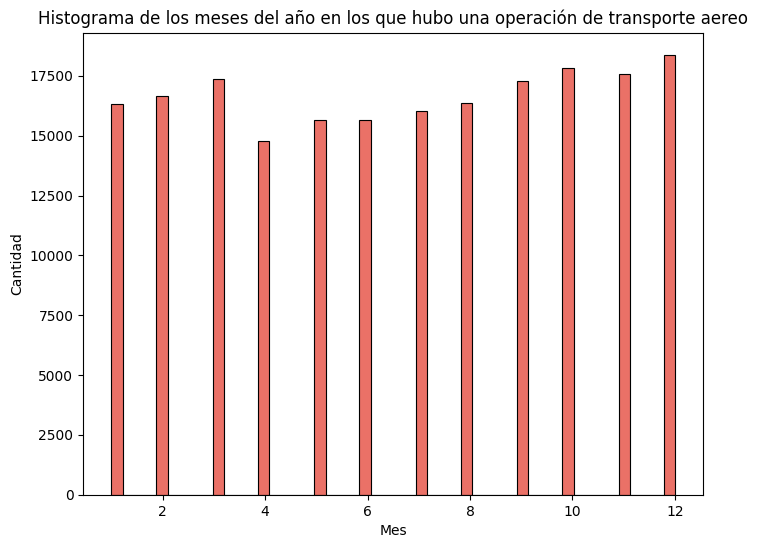

In [78]:
#Tomamos las dos columnas numericas, que son mes y hora bloque:
#Aquí hay que hacer sinceros con algo y es que en realidad son categóricas con clave numérica, igual haremos el histograma.
print(df['Mes'])
plt.figure(figsize=(8,6))
sns.histplot(df['Mes'], color='#E34234', bins=50)
plt.title('Histograma de los meses del año en los que hubo una operación de transporte aereo', fontsize=12)
plt.xlabel('Mes')
plt.ylabel('Cantidad')
plt.show()

In [79]:
df['Horas Bloque'] #revisamos las horas

,Horas Bloque
0,2.25
1,1.58
2,1.08
3,3.24
4,1.08
...,...
199788,54.91
199789,11.55
199790,105.27
199791,52.44


0           2.25
1           1.58
2           1.08
3           3.24
4           1.08
           ...  
199788     54.91
199789     11.55
199790    105.27
199791     52.44
199792      3.18
Name: Horas Bloque, Length: 199793, dtype: object


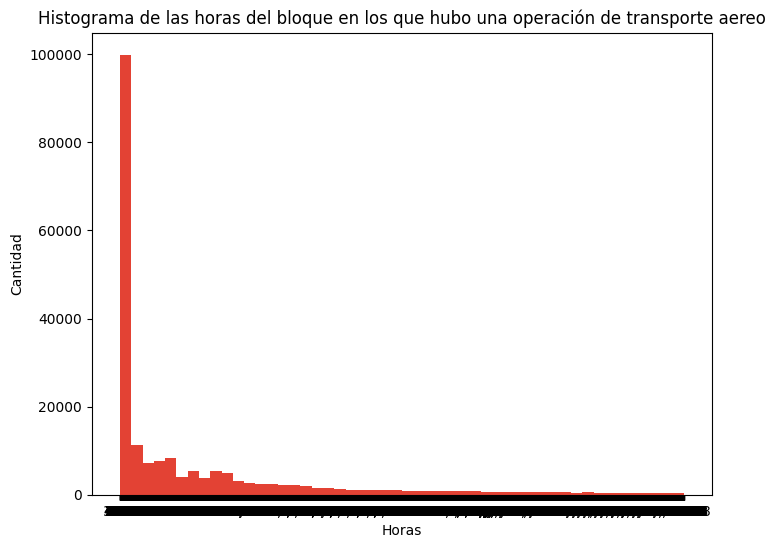

In [80]:
print(df['Horas Bloque'])

plt.figure(figsize=(8,6))
plt.hist(df['Horas Bloque'], color='#E34234', bins=50)
plt.title('Histograma de las horas del bloque en los que hubo una operación de transporte aereo', fontsize=12)
plt.xlabel('Horas')
plt.ylabel('Cantidad')
plt.show()

0          1
1          1
2          1
3          3
4          1
          ..
199788     5
199789     1
199790    10
199791     5
199792     1
Name: Número de Vuelos, Length: 199793, dtype: int64


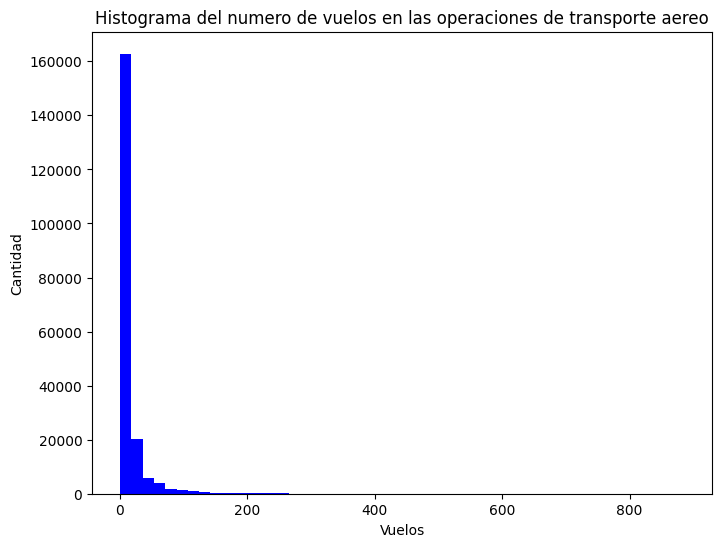

In [81]:
print(df['Número de Vuelos'])

plt.figure(figsize=(8,6))
plt.hist(df['Número de Vuelos'], color='blue', bins=50)
plt.title('Histograma del numero de vuelos en las operaciones de transporte aereo', fontsize=12)
plt.xlabel('Vuelos')
plt.ylabel('Cantidad')
plt.show()

#Graficos de densidades

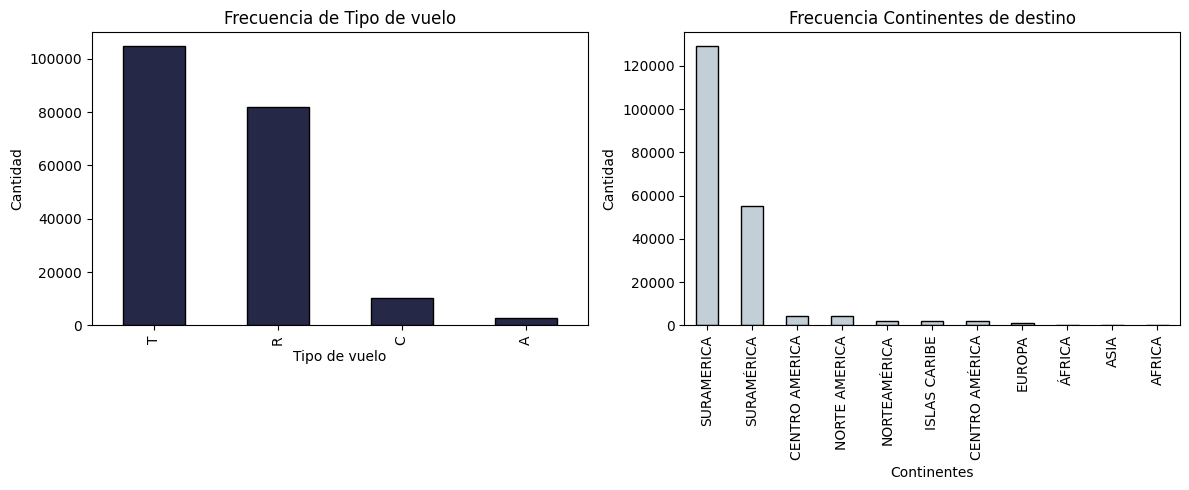

In [82]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5)) #Creamos un subplot para poder verlos lado a lado

df['Tipo Vuelo'].value_counts().plot(kind='bar', color='#262847', edgecolor='black',ax=ax[0]) #revisamos los tipos de vuelo con un value cons
#dado que tenemos una variable categórica
ax[0].set_title('Frecuencia de Tipo de vuelo')
ax[0].set_xlabel('Tipo de vuelo')
ax[0].set_ylabel('Cantidad')

df['Continente Destino'].value_counts().plot(kind='bar',color='#C2CFD7',edgecolor='black',ax=ax[1]) #Lo mismo hacemos con el continente de destino
ax[1].set_title('Frecuencia Continentes de destino')
ax[1].set_xlabel('Continentes')
ax[1].set_ylabel('Cantidad')



plt.tight_layout()
plt.show()

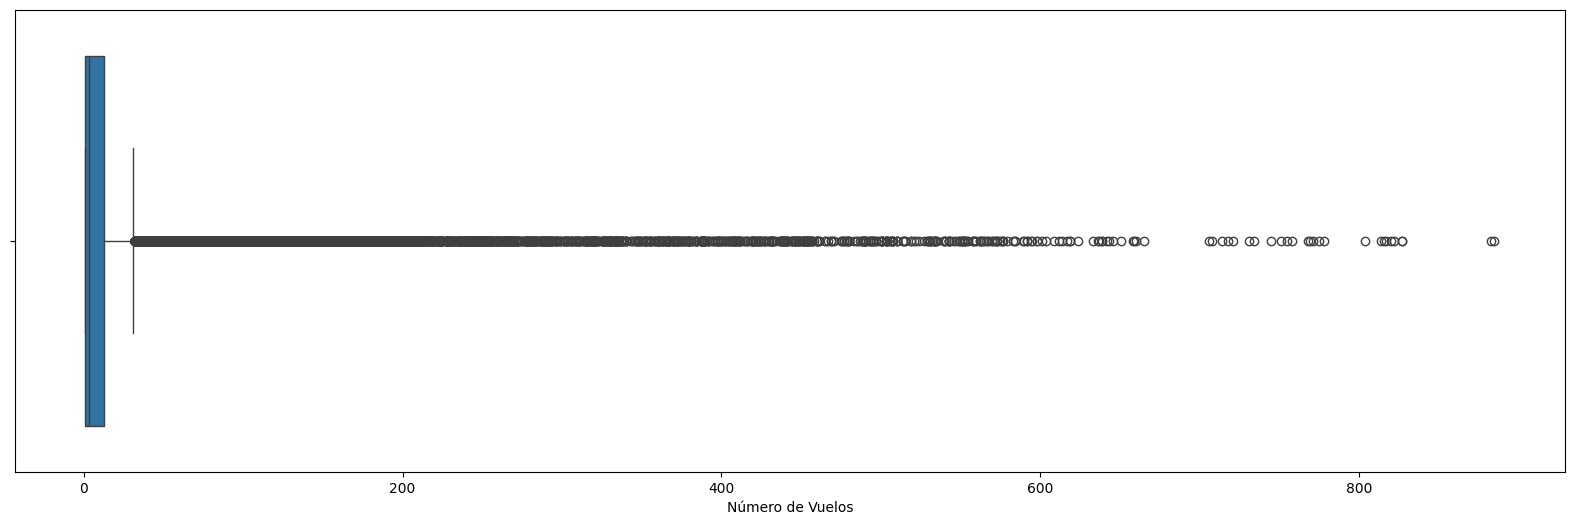

,Número de Vuelos
count,199793.000000
mean,13.740326
std,35.392005
min,1.000000
25%,1.000000
50%,3.000000
75%,13.000000
max,885.000000


In [83]:
#Identificacion de Outliers
df['Número de Vuelos'] #Frecuencia de vuelos
plt.figure(figsize=(20,6))
sns.boxplot(df['Número de Vuelos'], orient='h')
plt.show()

df['Número de Vuelos'].describe()

La mediana del numero de vuelos es: $3.000000


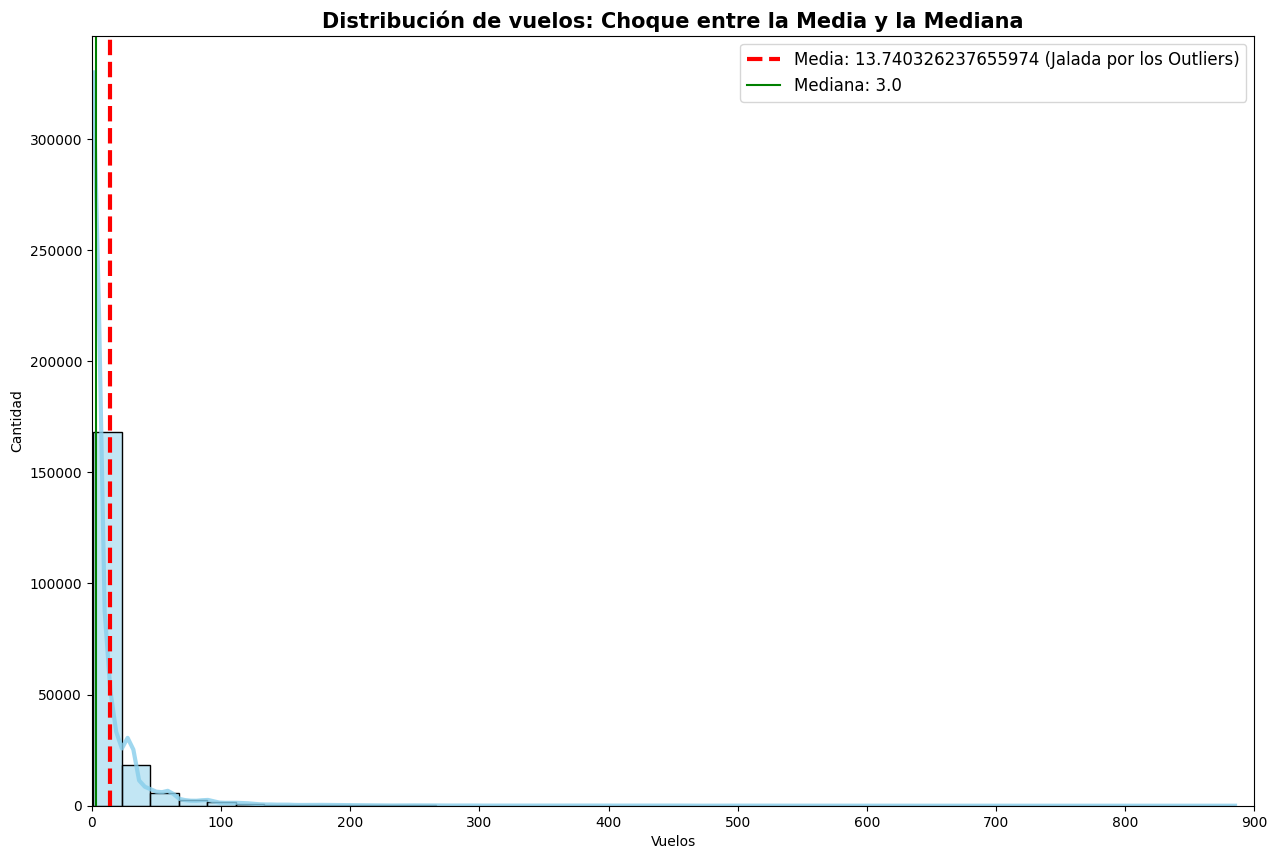

In [121]:
mediana_vuelos = df['Número de Vuelos'].median()
media_vuelos = df['Número de Vuelos'].mean()
print(f'La mediana del numero de vuelos es: ${mediana_vuelos:1f}')

plt.figure(figsize=(15,10))
datos_visuales = df[df['Número de Vuelos'] < 35000]
sns.histplot(datos_visuales['Número de Vuelos'], bins=40, color='skyblue', kde=True,
             line_kws={'linewidth': 3, 'color': 'navy', 'alpha': 0.8}) #Destacamos la envolvemnte en azul oscuro
#Aqui ponemos las lineas verticales de la media y la mediana.
plt.axvline(media_vuelos, color='red', linestyle = 'dashed', linewidth = 3, label=f'Media: {media_vuelos} (Jalada por los Outliers)')
plt.axvline(mediana_vuelos, color='green', linestyle = 'solid', label=f'Mediana: {mediana_vuelos}' )

plt.title('Distribución de vuelos: Choque entre la Media y la Mediana', fontsize= 15, fontweight ='bold')
plt.xlabel('Vuelos')
plt.ylabel('Cantidad')
plt.xlim(0,900)
plt.legend(fontsize=12)
plt.show()

In [85]:
Q1 = df['Número de Vuelos'].quantile(0.25)
Q3 = df['Número de Vuelos'].quantile(0.75)
IQR = Q3 - Q1
print(f'El IQR del número de vuelos es: ', IQR) #Encontramos el rango intercuartilico con los cuartiles

El IQR del número de vuelos es:  12.0


# Análisis bivariado y temporal

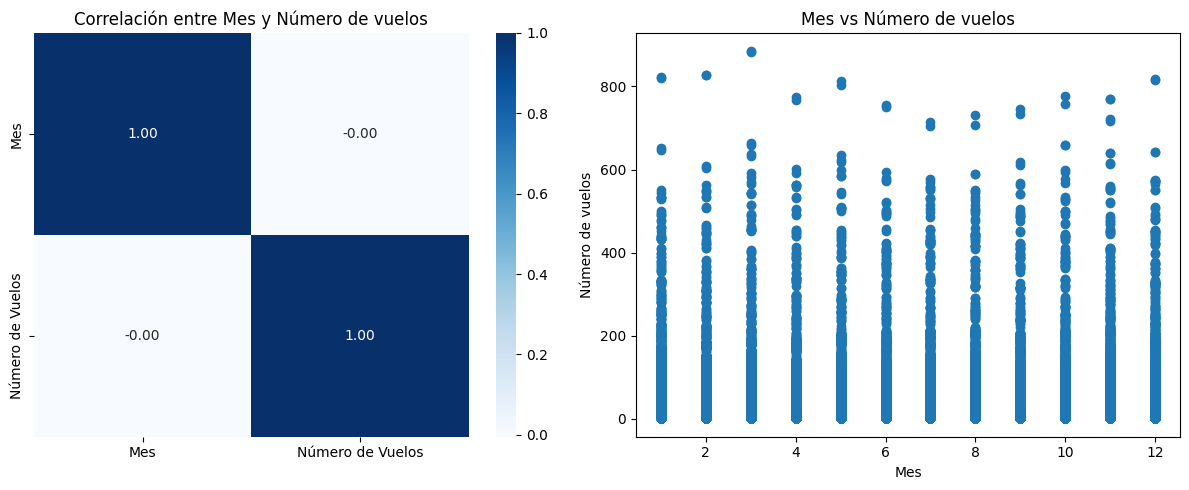

In [86]:

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

corr = df[['Mes', 'Número de Vuelos']].corr()
sns.heatmap(corr, annot=True, cmap='Blues', fmt='.2f', ax=ax[0])

ax[0].set_title('Correlación entre Mes y Número de vuelos')

ax[1].scatter(df['Mes'], df['Número de Vuelos'])

ax[1].set_title('Mes vs Número de vuelos')
ax[1].set_xlabel('Mes')
ax[1].set_ylabel('Número de vuelos')

plt.tight_layout()
plt.show()

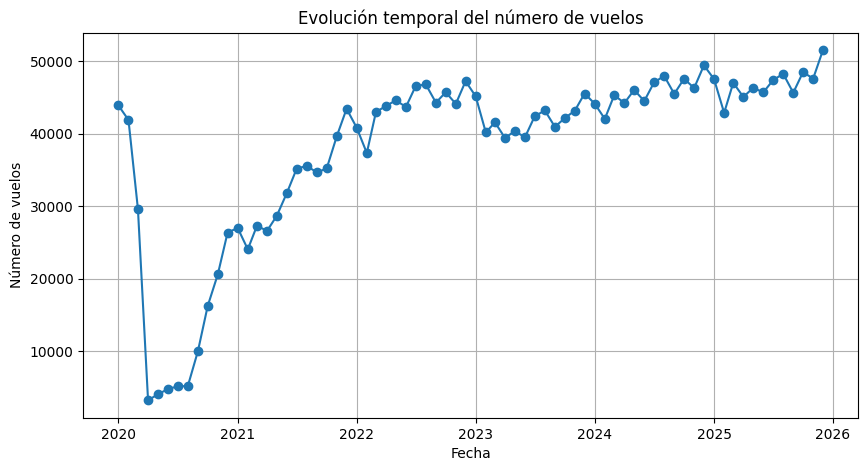

In [87]:
# Evolución temporal de al menos una variable de demanda (pasajeros o vuelos) a nivel agregado.
df['Año'] = df['Año'].astype(str).str.replace(',', '') #limpiamos para quitar las comas

df['Fecha'] = pd.to_datetime(df['Año'].astype(str) + '-' + df['Mes'].astype(str))
vuelos_fecha = df.groupby('Fecha')['Número de Vuelos'].sum()

# Graficar
plt.figure(figsize=(10,5))

plt.plot(vuelos_fecha.index, vuelos_fecha.values, marker='o')

plt.title('Evolución temporal del número de vuelos')
plt.xlabel('Fecha')
plt.ylabel('Número de vuelos')

plt.grid(True)

plt.show()

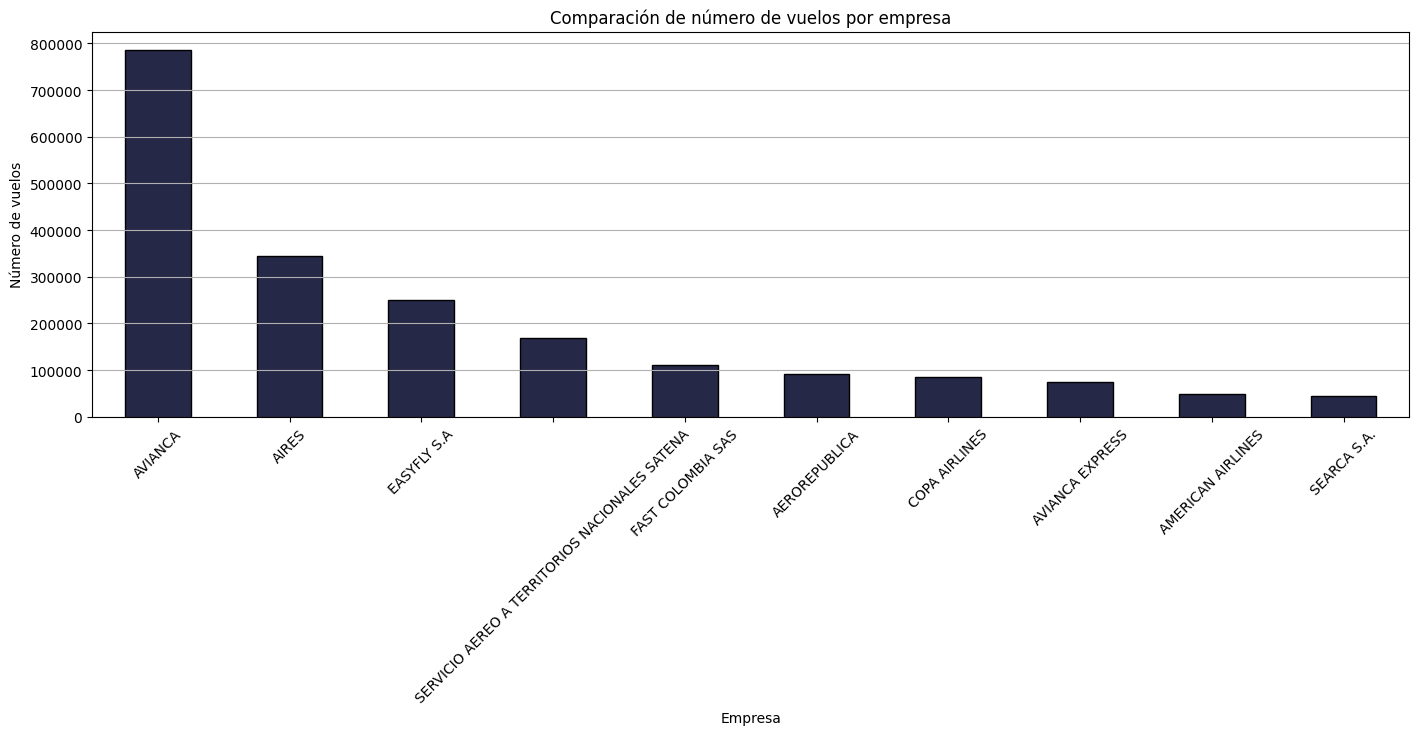

In [88]:
# Comparación entre grupos: por empresa, tipo de tráfico o corredor.
# Top 10 empresas por número de vuelos
empresa_vuelos = (df.groupby('Nombre')['Número de Vuelos'].sum().sort_values(ascending=False).head(10))

# Graficar
plt.figure(figsize=(17,5))

empresa_vuelos.plot(kind='bar', color='#262847', edgecolor='black')

plt.title('Comparación de número de vuelos por empresa')
plt.xlabel('Empresa')
plt.ylabel('Número de vuelos')

plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

#Factor de ocupación (load factor)

In [93]:
df['Pasajeros A Bordo'].head(30)

,Pasajeros A Bordo
0,5
1,2
2,3
3,6
4,1
5,3
6,0
7,3
8,1
9,0


In [90]:
df['Sillas Ofrecidas'].describe()

,Sillas Ofrecidas
count,199793
unique,10879
top,0
freq,122133


In [101]:
# Calculamos pasajeros transportados y sillas ofrecidas.

#Convertir columnas a numéricas
df['Pasajeros A Bordo'] = pd.to_numeric(df['Pasajeros A Bordo'], errors='coerce') #Aqui usamos la función de pandas dado que pasajeros a bordo sale como
# categorica (suena coherente) pero aquí necesitamos los valores numéricos sin perder de vista la categoría
df['Sillas Ofrecidas'] = pd.to_numeric(df['Sillas Ofrecidas'], errors='coerce') #Lo mismo con las sillas ofrecidas

#Usamos errors='coerce' para que lo que no coincida con un valor numérico se deje como N/A. Se que tal vez no es la opción mas elegante
# y lo tengo en cuenta, pero tampoco se solicita un tratamiento mas profundo.

#factor de ocupación
df['Factor Ocupacion'] = np.where(df['Sillas Ofrecidas'] != 0, df['Pasajeros A Bordo'] / df['Sillas Ofrecidas'],np.nan)
#Encontramos el factor de ocupación siempre y cuando el denominador no sea 0.


In [102]:
df['Pasajeros A Bordo'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 199793 entries, 0 to 199792
Series name: Pasajeros A Bordo
Non-Null Count   Dtype  
--------------   -----  
157895 non-null  float64
dtypes: float64(1)
memory usage: 1.5 MB


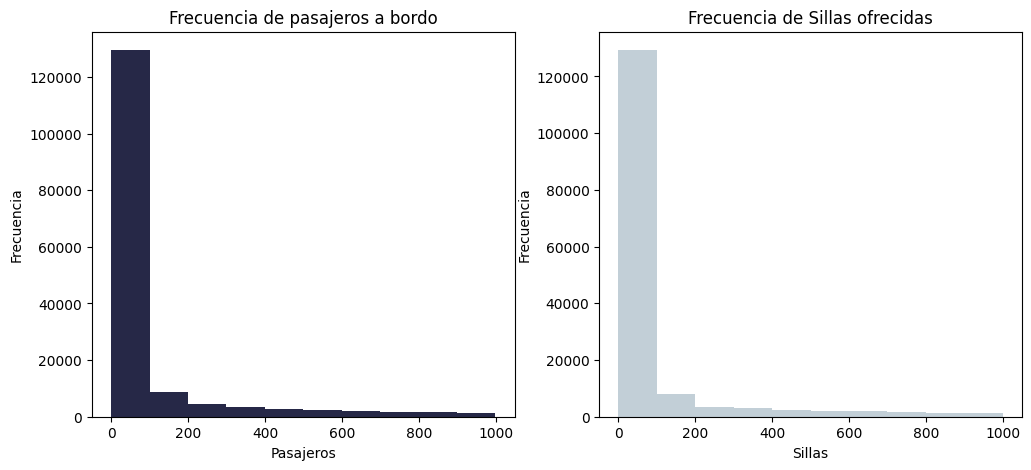

In [103]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))
df['Pasajeros A Bordo'].plot(kind='hist', color='#262847', ax=ax[0])
df['Sillas Ofrecidas'].plot(kind='hist', color='#C2CFD7', ax=ax[1])
ax[0].set_title('Frecuencia de pasajeros a bordo')
ax[0].set_xlabel('Pasajeros')
ax[0].set_ylabel('Frecuencia')
ax[1].set_title('Frecuencia de Sillas ofrecidas')
ax[1].set_xlabel('Sillas')
ax[1].set_ylabel('Frecuencia')
plt.show()

In [104]:
df['Sillas Ofrecidas'].describe()

,Sillas Ofrecidas
count,153923.000000
mean,66.916432
std,178.859061
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,999.000000


In [105]:
df[['Pasajeros A Bordo', 'Sillas Ofrecidas', 'Factor Ocupacion']]

,Pasajeros A Bordo,Sillas Ofrecidas,Factor Ocupacion
0,5.0,0.0,NaN
1,2.0,0.0,NaN
2,3.0,0.0,NaN
3,6.0,0.0,NaN
4,1.0,0.0,NaN
...,...,...,...
199788,NaN,NaN,NaN
199789,129.0,388.0,0.332474
199790,NaN,NaN,NaN
199791,NaN,NaN,NaN


In [106]:
# Describir la distribución del indicador.

df['Factor Ocupacion'].describe()

,Factor Ocupacion
count,31789.000000
mean,0.709682
std,0.238775
min,0.000000
25%,0.600962
50%,0.765472
75%,0.888199
max,1.000000


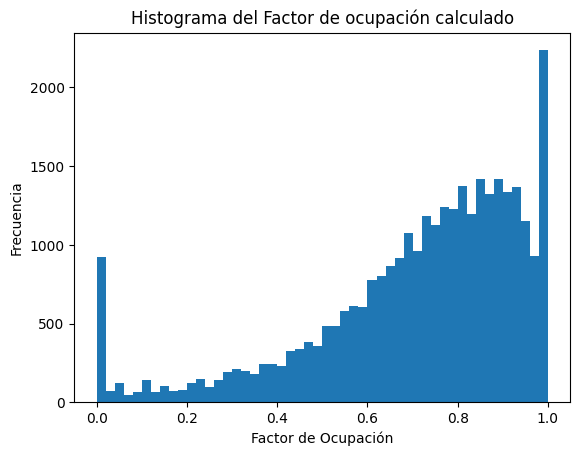

In [107]:
plt.hist(df['Factor Ocupacion'], bins=50)
plt.title('Histograma del Factor de ocupación calculado')
plt.xlabel('Factor de Ocupación')
plt.ylabel('Frecuencia')
plt.show()

In [108]:
 #Identificar empresas o rutas con valores extremos.
#Total vuelos por empresa
empresa_vuelos = (df.groupby('Nombre')['Número de Vuelos'].sum().sort_values(ascending=False))
print('*'*70)
#Empresas con más vuelos
print("Empresas con más vuelos:")
print(empresa_vuelos.head())
print('*'*70)
#Empresas con menos vuelos
print("Empresas con menos vuelos:")
print(empresa_vuelos.tail())

**********************************************************************
Empresas con más vuelos:
Nombre
AVIANCA                                           785510
AIRES                                             343861
EASYFLY S.A                                       251053
SERVICIO AEREO A TERRITORIOS NACIONALES SATENA    168311
FAST COLOMBIA SAS                                 110866
Name: Número de Vuelos, dtype: int64
**********************************************************************
Empresas con menos vuelos:
Nombre
ADVANCE AIR CHARTERS              1
IBC AIRWAYS                       1
ELDORADO                          1
RUTAS AEREAS. C.A (RUTACA)        1
TAP PORTUGAL SUCURSAL COLOMBIA    1
Name: Número de Vuelos, dtype: int64


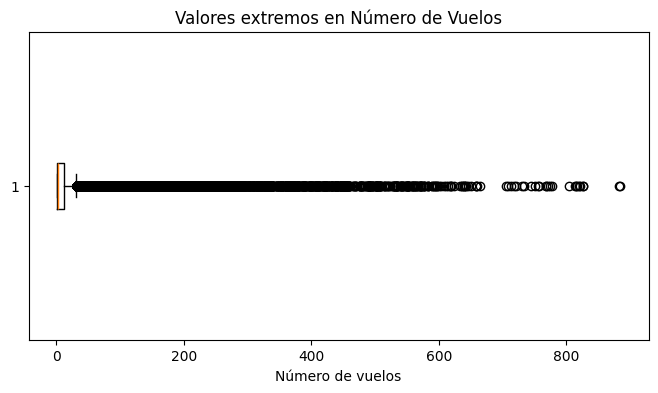

In [109]:
plt.figure(figsize=(8,4))
plt.boxplot(df['Número de Vuelos'], vert=False)
plt.title('Valores extremos en Número de Vuelos')
plt.xlabel('Número de vuelos')
plt.show()

#Interpretación operacional de los resultados

### 1. Sillas ofrecidas
Los resultados muestran una alta dispersión, se observa tambien que el 25%, 50% y el 75% de los registros tienen valor 0, la desviación estándar es fuerte, el maximo de sillas alcanzan 999... probablemente outliers

### 2. Factor de ocupación

El factor de ocupación promedio es aproximadamente 0.71 (71%), lo que indica que, en promedio, las aerolíneas utilizan cerca del 71% de su capacidad disponible de asientos.

Este valor es relevante en el área operacional por dos motivos principales:

1. Se refleja un nivel relativamente eficiente de utilización de capadiad
2. Se evidencia una demanda estable en gran parte de las rutas analizadas.

La mediana de 0.77 indica que más de la mitad de los vuelos presentan ocupaciones cercanas al 77%, mientras que el tercer cuartil (0.89) evidencia que una parte importante de las operaciones trabaja con altos niveles de ocupación.

Tambien destaco que la existencia de vuelos con ocupación de 1 indica operaciones completamente llenas, lo cual podría asociarse:

1. Alta demanda en rutas específicas
2. Temporadas pico
3. Limitaciones en la oferta de sillas

### 3. Empresas con mayor

Las empresas con mayor volumen operativo son:
Avianca, Aires, EASYFLY, Satena, Fast Colombia SAS.

Esto evidencia una fuerte concentración dle mercado aéreo colombiano en pocas compañias, especialmente en aerolíneas con amplia cobertura nacional y alta frecuencia de operación.

Operacionalmente esto significa:
1. Avianca lidera ampliamente  el mercado.
2. EASYFLY y SATENA muestran una importante participación regional
3. mientras que FAST COLOMBIA SAS refleja el crecimiento del modelo de bajo costo.


#Pregunta de Criterio libre

##¿Existe relación entre el nivel de ocupación de los vuelos y el tipo de tráfico aéreo?

Considero que esto es importante porque nos permite identificar los tipos de vuelos, la eficiencia operacional, demanda, rentabilidad potencial y comportamiento del mercado aéreo.

Esto fue escrito despues de revisar todas las graficas y conclusiones:
###No considero que exista relación segun el tráfico aéreo, yo creo que depende de el mes del año mas que del tipo de tráfico aéreo

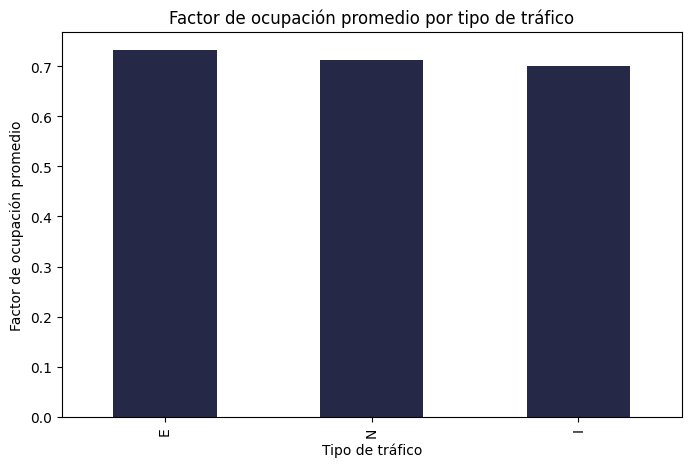

In [113]:
#Vamos a ver la ocupación_trafico

ocupacion_trafico = (df.groupby('Tráfico')['Factor Ocupacion'].mean().sort_values(ascending=False))
ocupacion_trafico.plot(kind='bar', figsize=(8,5), color='#262847')
plt.title('Factor de ocupación promedio por tipo de tráfico')
plt.xlabel('Tipo de tráfico')
plt.ylabel('Factor de ocupación promedio')

plt.show()

In [114]:
df['Tráfico'].unique()

array(['N', 'I', 'E'], dtype=object)

Bueno, es bastante interesante porque muestra algo importante operacionalmente:

Los 3 tipos de tráfico tienen factores de ocupación muy similares, según la gráfica está en unos 70% aproximadamente.

No existen diferencias muy grandes entre los distintos tipos de tráfico.
El tráfico 'E' parece tener la mayor eficiencia de ocupación mientras que el tráfico 'I' tiene el menor promedio, aunque la diferencia es bastante pequeña...

Podemos decir que aunque existen diferencias entre categorías no son suficientemente grandes como para decir que hay una diferenciación extrema en la eficiencia de ocupación en el mercado aéreo.

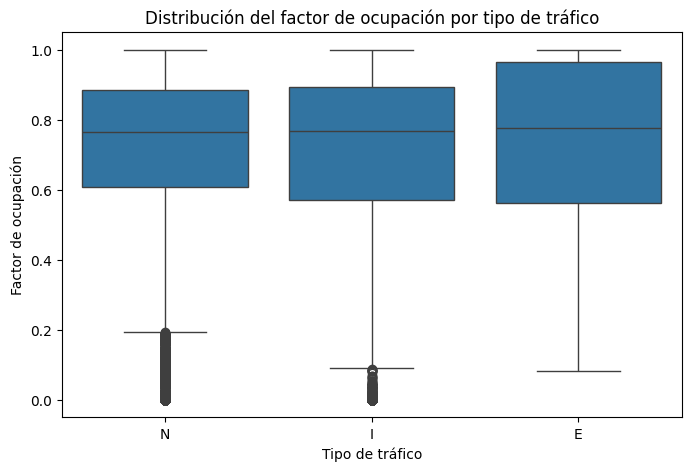

In [115]:
#Boxplot
plt.figure(figsize=(8,5))
sns.boxplot(x='Tráfico', y='Factor Ocupacion', data=df)

plt.title('Distribución del factor de ocupación por tipo de tráfico')
plt.xlabel('Tipo de tráfico')
plt.ylabel('Factor de ocupación')

plt.show()

Tenemos algo muy similar al grafico de factor de ocupación promedio por tipo de tráfico, sin embargo, aqui vemos mejor como se distribuyen según el tipo y su frecuencia porcentual del factor de ocupación, identificamos una fuerte presencia de outliers en el trafico tipo N, pero tambien una caja algo más angosta que los demás tipos. El trafico tipo E es quien tiene menor presenia de outliers en el factor de ocupación.

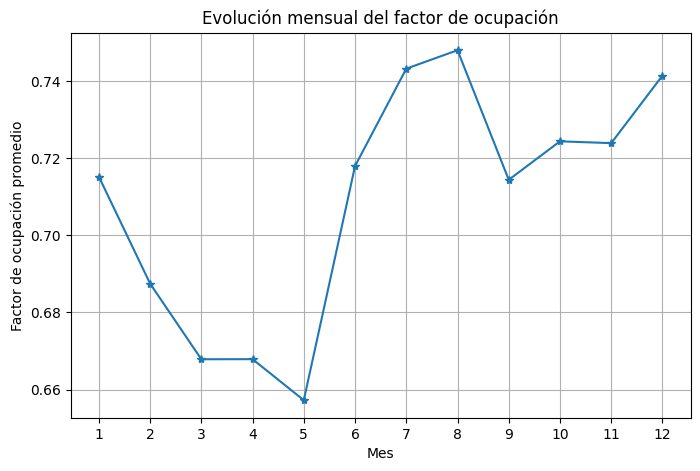

In [118]:
#Veamos como cambia el factor de ocupación segun los meses

ocupacion_mes = (df.groupby('Mes')['Factor Ocupacion'].mean())
#Aquí decidimos usar la media dado que el factor es muy variable
plt.figure(figsize=(8,5))
plt.plot(ocupacion_mes.index, ocupacion_mes.values, marker='*')
plt.title('Evolución mensual del factor de ocupación')
plt.xlabel('Mes')
plt.ylabel('Factor de ocupación promedio')

plt.xticks(range(1,13))
plt.grid(True)
plt.show()

Aquí podemos notar algo interesante y es que a fines de año tenemos un aumento fuerte en la ocupación (el factor) en este transporte aéreo, tambien en el principio del año, podria deberse a la presencia de ciertos vuelos tanto comerciales como de carga en temporadas puntuales de distintos paises extranjeros... Podria deberse a diferentes estaciones del año, periodos de influencia económica de los mercados y temporadas de viaje.

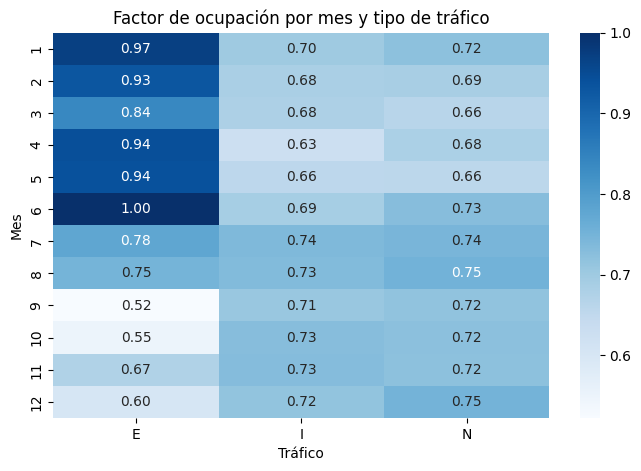

In [119]:
tabla = df.pivot_table(values='Factor Ocupacion',
                       index='Mes', columns='Tráfico', aggfunc='mean')

plt.figure(figsize=(8,5))
sns.heatmap(tabla, annot=True, cmap='Blues', fmt='.2f')
plt.title('Factor de ocupación por mes y tipo de tráfico')

plt.show()

Aquí tenemos el Heatmap del Mes vs Tipo de tráfico, vemos un comportamiento muy similar al que ya hemos encontrado según los meses pero ahora lo vemos separado por tipo de tráfico...

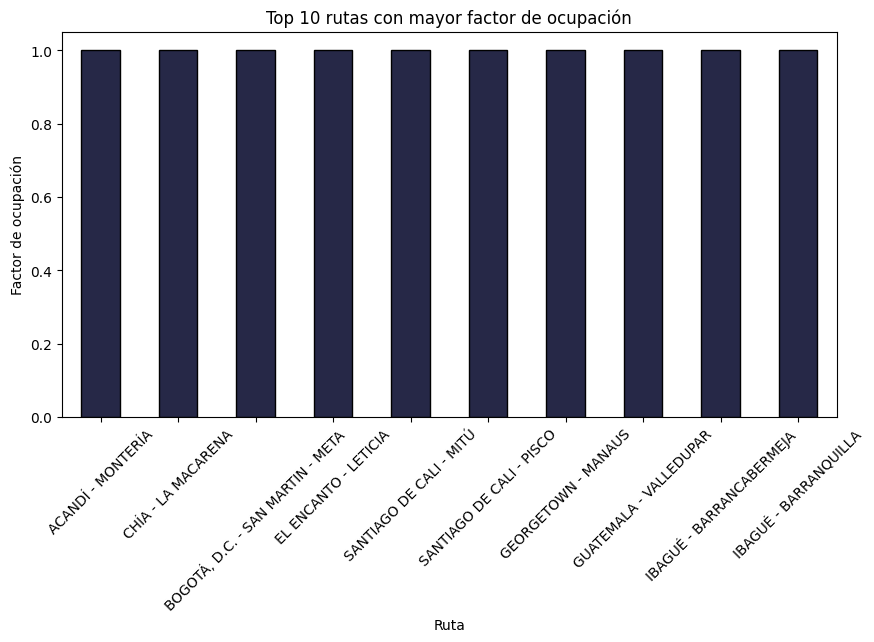

In [120]:
#Y, finalmente, top rutas con mayor ocupación

df['Ruta'] = df['Ciudad Origen']+ ' - ' +df['Ciudad Destino']

rutas = (df.groupby('Ruta')['Factor Ocupacion'].mean().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,5))
rutas.plot(kind='bar', color='#262847', edgecolor='black')

plt.title('Top 10 rutas con mayor factor de ocupación')
plt.xlabel('Ruta')
plt.ylabel('Factor de ocupación')

plt.xticks(rotation=45)

plt.show()